In [1]:
import numpy as np
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import warnings

warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt

## Outlier analysis from CSV samples

This section samples the monthly CSV files instead of querying the full PostgreSQL table. The goal is to keep each notebook cell quick and memory-safe while still checking the distribution of `hours` and `fishing_hours`.

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "fleet_monthly").exists():
    PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "fleet_monthly"
CSV_FILES = sorted(DATA_DIR.glob("**/*.csv"))
METRICS = ["hours", "fishing_hours"]
P99_CAPS = {"hours": 242.054268, "fishing_hours": 92.962253}

len(CSV_FILES), CSV_FILES[0], CSV_FILES[-1]

(108,
 WindowsPath('c:/Users/user/Documents/Projects/DataViz Project/data/fleet_monthly/fleet-monthly-csvs-10-v3-2016/fleet-monthly-csvs-10-v3-2016-01-01.csv'),
 WindowsPath('c:/Users/user/Documents/Projects/DataViz Project/data/fleet_monthly/fleet-monthly-csvs-10-v3-2024/fleet-monthly-csvs-10-v3-2024-12-01.csv'))

### Build a memory-safe sample

The helper below reads each CSV in chunks and samples a small number of rows per chunk. Increase `frac` slightly if you want a larger sample, but keep it low so the notebook stays responsive.

In [3]:
def sample_fleet_csvs(files, frac=0.001, max_rows_per_chunk=250, chunksize=100_000, random_state=42):
    sampled_chunks = []
    columns = [
        "date",
        "year",
        "month",
        "cell_ll_lat",
        "cell_ll_lon",
        "flag",
        "geartype",
        "hours",
        "fishing_hours",
        "mmsi_present",
    ]

    for file_path in files:
        for chunk in pd.read_csv(file_path, usecols=columns, chunksize=chunksize, low_memory=False):
            sample_size = min(max_rows_per_chunk, max(1, int(len(chunk) * frac)))
            sampled_chunks.append(chunk.sample(n=sample_size, random_state=random_state))

    sample = pd.concat(sampled_chunks, ignore_index=True)
    sample["date"] = pd.to_datetime(sample["date"])
    for metric in METRICS:
        sample[metric] = pd.to_numeric(sample[metric], errors="coerce")
    return sample

fleet_sample = sample_fleet_csvs(CSV_FILES)
fleet_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107454 entries, 0 to 107453
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   date           107454 non-null  datetime64[ns]
 1   year           107454 non-null  int64         
 2   month          107454 non-null  int64         
 3   cell_ll_lat    107454 non-null  float64       
 4   cell_ll_lon    107454 non-null  float64       
 5   flag           107454 non-null  object        
 6   geartype       107454 non-null  object        
 7   hours          107454 non-null  float64       
 8   fishing_hours  107454 non-null  float64       
 9   mmsi_present   107454 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(3), object(2)
memory usage: 8.2+ MB


In [4]:
def summarize_metric(series: pd.Series, metric: str) -> dict:
    clean = series.dropna()
    p25 = clean.quantile(0.25)
    p75 = clean.quantile(0.75)
    iqr = p75 - p25
    return {
        "metric": metric,
        "sampled_rows": int(clean.shape[0]),
        "min_value": clean.min(),
        "mean_value": clean.mean(),
        "stddev_value": clean.std(ddof=0),
        "p25": p25,
        "median": clean.median(),
        "p75": p75,
        "sample_p95": clean.quantile(0.95),
        "sample_p99": clean.quantile(0.99),
        "max_value": clean.max(),
        "iqr_mild_upper": p75 + 1.5 * iqr,
        "iqr_extreme_upper": p75 + 3.0 * iqr,
        "p99_cap": P99_CAPS[metric],
        "sample_rows_above_cap": int((clean > P99_CAPS[metric]).sum()),
    }

outlier_summary = pd.DataFrame([summarize_metric(fleet_sample[metric], metric) for metric in METRICS])
outlier_summary

,metric,sampled_rows,min_value,mean_value,stddev_value,p25,median,p75,sample_p95,sample_p99,max_value,iqr_mild_upper,iqr_extreme_upper,p99_cap,sample_rows_above_cap
0,hours,107454,0.0,15.491469,431.524028,0.5166,1.0963,3.864400,32.053085,233.264117,132354.9036,8.886100,13.9078,242.054268,1033
1,fishing_hours,107454,0.0,5.563871,45.674850,0.0000,0.0000,1.519375,16.541485,94.788875,3999.2708,3.798438,6.0775,92.962253,1096


### Inspect sampled rows above the cap

These rows come only from the CSV sample. They show examples of values that would be capped in PostgreSQL.

In [5]:
sample_outliers = []
for metric in METRICS:
    rows = fleet_sample.loc[fleet_sample[metric] > P99_CAPS[metric]].copy()
    if rows.empty:
        continue
    rows.insert(0, "outlier_metric", metric)
    rows.insert(1, "outlier_value", rows[metric])
    rows.insert(2, "p99_cap", P99_CAPS[metric])
    sample_outliers.append(rows.nlargest(25, metric))

top_outliers = pd.concat(sample_outliers, ignore_index=True) if sample_outliers else pd.DataFrame()
top_outliers

,outlier_metric,outlier_value,p99_cap,date,year,month,cell_ll_lat,cell_ll_lon,flag,geartype,hours,fishing_hours,mmsi_present
0,hours,132354.9036,242.054268,2023-03-01,2023,3,35.1,119.3,CHN,trawlers,132354.9036,3473.0891,356
1,hours,18144.8493,242.054268,2022-10-01,2022,10,30.4,122.3,CHN,trawlers,18144.8493,67.2411,185
2,hours,14936.2830,242.054268,2020-03-01,2020,3,57.7,-152.5,USA,trawlers,14936.2830,10.7327,46
3,hours,14749.3686,242.054268,2024-02-01,2024,2,26.3,119.9,CHN,fishing,14749.3686,256.2383,170
4,hours,13807.7122,242.054268,2021-08-01,2021,8,32.0,121.5,CHN,fishing,13807.7122,587.1294,174
5,hours,13566.5624,242.054268,2022-12-01,2022,12,21.5,111.8,CHN,trawlers,13566.5624,307.9638,332
6,hours,8659.8619,242.054268,2022-09-01,2022,9,-42.8,-65.1,ARG,trawlers,8659.8619,776.3886,112
7,hours,7031.5725,242.054268,2024-11-01,2024,11,21.8,113.2,CHN,trawlers,7031.5725,2482.7586,124
8,hours,6510.9091,242.054268,2019-12-01,2019,12,68.0,13.5,NOR,set_gillnets,6510.9091,2.8505,15
9,hours,6256.9869,242.054268,2023-01-01,2023,1,70.8,29.0,NOR,set_gillnets,6256.9869,1.1505,16


In [6]:
capped_sample = fleet_sample.copy()
for metric, cap in P99_CAPS.items():
    capped_sample[f"{metric}_capped"] = capped_sample[metric].clip(upper=cap)

cap_effect_summary = pd.DataFrame(
    [
        {
            "metric": metric,
            "cap": cap,
            "sample_rows_above_cap": int((fleet_sample[metric] > cap).sum()),
            "sample_mean_before": fleet_sample[metric].mean(),
            "sample_mean_after": capped_sample[f"{metric}_capped"].mean(),
            "sample_max_before": fleet_sample[metric].max(),
            "sample_max_after": capped_sample[f"{metric}_capped"].max(),
        }
        for metric, cap in P99_CAPS.items()
    ]
)
cap_effect_summary

,metric,cap,sample_rows_above_cap,sample_mean_before,sample_mean_after,sample_max_before,sample_max_after
0,hours,242.054268,1033,15.491469,8.517812,132354.9036,242.054268
1,fishing_hours,92.962253,1096,5.563871,3.551317,3999.2708,92.962253


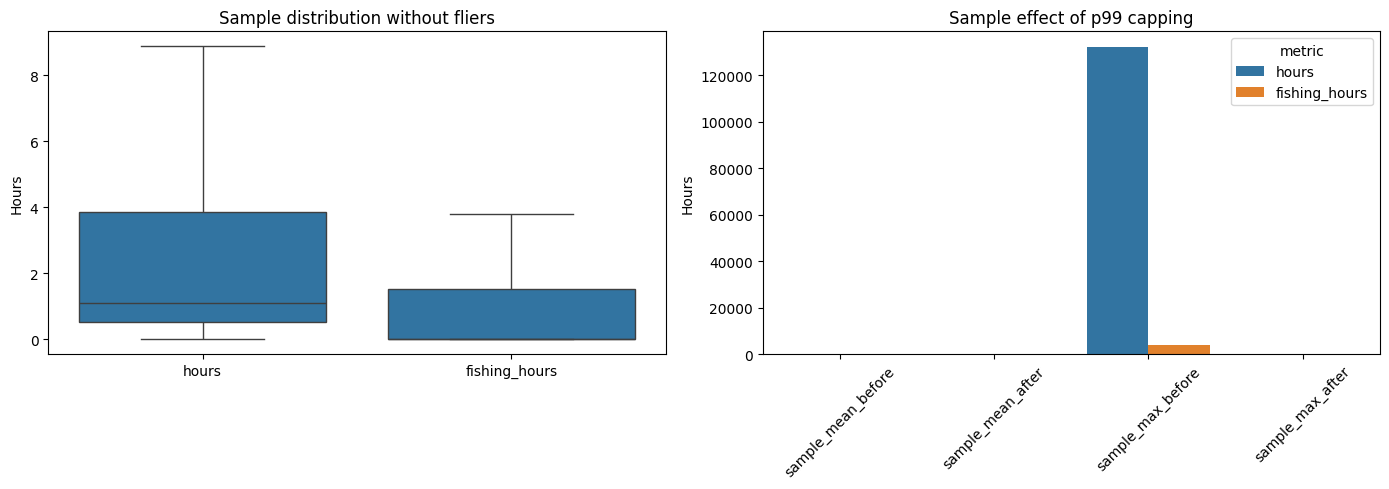

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_sample = fleet_sample[METRICS].melt(var_name="metric", value_name="value")
sns.boxplot(data=plot_sample, x="metric", y="value", showfliers=False, ax=axes[0])
axes[0].set_title("Sample distribution without fliers")
axes[0].set_xlabel("")
axes[0].set_ylabel("Hours")

cap_plot = cap_effect_summary.melt(
    id_vars=["metric", "cap"],
    value_vars=["sample_mean_before", "sample_mean_after", "sample_max_before", "sample_max_after"],
    var_name="stat",
    value_name="value",
)
sns.barplot(data=cap_plot, x="stat", y="value", hue="metric", ax=axes[1])
axes[1].set_title("Sample effect of p99 capping")
axes[1].set_xlabel("")
axes[1].set_ylabel("Hours")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()